# Analisis descriptivo y exploratorio del dataset interno

## Carga de datos y librerias

In [3]:
# Build an EDA (Exploratory Data Analysis) for the dataset data/data/raw/inventario_subastas_simon.csv
import numpy
import pandas
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sys
from pathlib import Path

# Agregar el directorio raíz del proyecto al sys.path
BASE_DIR = Path().resolve().parent
if str(BASE_DIR) not in sys.path:
    sys.path.append(str(BASE_DIR))

import src.data_processing as dp

df_raw = pandas.read_csv('/workspaces/Caso-de-Uso-Analista-de-Datos/data/data/raw/inventario_subastas_simon.csv')

## Diagnóstico de Salud de los Datos Crudos & Perfilado Inicial

In [6]:
print("Valores nulos por columna:")
print(df_raw.isnull().sum())
print("\nNúmero de filas duplicadas:")
print(df_raw.duplicated().sum())

Valores nulos por columna:
ID_Vehiculo                0
Marca                      0
Linea                      0
Modelo                     0
Kilometraje                0
Estado_Vehiculo            0
Costo_Adquisicion_COP      0
Valor_Fasecolda_COP        0
Dias_en_Inventario         0
Canal_Asignado             0
Precio_Reserva_COP         0
Precio_Final_Venta_COP     0
Estado_Subasta             0
ID_Comprador              97
Tipo_Comprador            97
dtype: int64

Número de filas duplicadas:
0


In [7]:
print("\nResumen estadístico del dataframe crudo:")
df_raw.describe()


Resumen estadístico del dataframe crudo:


,Modelo,Kilometraje,Costo_Adquisicion_COP,Valor_Fasecolda_COP,Dias_en_Inventario,Precio_Reserva_COP,Precio_Final_Venta_COP
count,350.000000,350.000000,3.500000e+02,3.500000e+02,350.000000,3.500000e+02,3.500000e+02
mean,2020.840000,94306.545714,6.679057e+07,8.341743e+07,48.685714,7.164057e+07,5.733286e+07
std,1.680019,35951.606311,2.890665e+07,3.586153e+07,37.376173,3.120524e+07,4.535864e+07
min,2018.000000,25122.000000,2.720000e+07,3.520000e+07,15.000000,2.940000e+07,0.000000e+00
25%,2020.000000,67833.750000,4.650000e+07,5.725000e+07,15.000000,4.967500e+07,0.000000e+00
50%,2021.000000,89998.500000,6.330000e+07,7.745000e+07,45.000000,6.755000e+07,6.100000e+07
75%,2022.000000,118544.000000,7.682500e+07,9.672500e+07,60.000000,8.155000e+07,8.397500e+07
max,2024.000000,198423.000000,1.781000e+08,2.104000e+08,180.000000,1.977000e+08,2.377000e+08


### Limpieza de datos, construcción de indices y enriquecimiento con datos externos.
Usaremos las funciones modulares escritas en src/data_processing.py para estas tareas.

In [8]:
df = dp.cargar_y_procesar_datos('/workspaces/Caso-de-Uso-Analista-de-Datos/data/data/raw/inventario_subastas_simon.csv')
df_enriched = dp.enriquecer_con_fuentes_externas(df, '/workspaces/Caso-de-Uso-Analista-de-Datos/data/data/external/ref_mercado_runt_fasecolda.csv')

In [17]:
df.head()

,ID_Vehiculo,Marca,Linea,Modelo,Kilometraje,Estado_Vehiculo,Costo_Adquisicion_COP,Valor_Fasecolda_COP,Dias_en_Inventario,Canal_Asignado,...,ID_Comprador,Tipo_Comprador,Win_Rate_Flag,Porcentaje_Recuperacion,Spread_Puja_COP,Ratio_Costo_Fasecolda,Ratio_Reserva_Fasecolda,Categoria_Fasecolda,Tramo_Aging,Holding_Cost_COP
0,SIM-1001,Toyota,Hilux,2022,79036,Excelente,147800000.0,175000000.0,30,Subasta Virtual,...,CLI-153,Financiera Partner,1,119.688769,21200000.0,0.844571,0.889714,Fair Value,<=30 días,2.217000e+06
1,SIM-1002,Hyundai,Tucson,2024,40054,Excelente,93000000.0,105800000.0,45,Subasta Virtual,...,CLI-116,Dealer / Reventa,1,106.236559,-900000.0,0.879017,0.942344,Overpriced,31-60 días,2.100327e+06
2,SIM-1003,Renault,Duster,2020,139075,Bueno,58100000.0,73100000.0,45,Subasta Virtual,...,CLI-126,Dealer / Reventa,1,119.449225,4700000.0,0.794802,0.885089,Fair Value,31-60 días,1.312140e+06
3,SIM-1004,Renault,Kwid,2019,159820,Bueno,33000000.0,40400000.0,15,Subasta Virtual,...,CLI-104,Dealer / Reventa,1,113.030303,1100000.0,0.816832,0.896040,Fair Value,<=30 días,2.465788e+05
4,SIM-1005,Chevrolet,Tracker,2022,79090,Excelente,75300000.0,87200000.0,120,Subasta Virtual,...,CLI-118,Empresa Flotilla,1,109.960159,5700000.0,0.863532,0.884174,Overpriced,>90 días,4.620675e+06


## Análisis de Antigüedad y Dinámica de Inventario

### Distribución de días en el inventario
El 50% central de los vehículos se mantienen en el inventario entre 15 a 60 días. Es decir, hay un 25% que ha estado en el inventario por más de 2 meses, llegando a un máximo de 6 meses.

<Axes: title={'center': 'Boxplot de Días en Inventario'}>

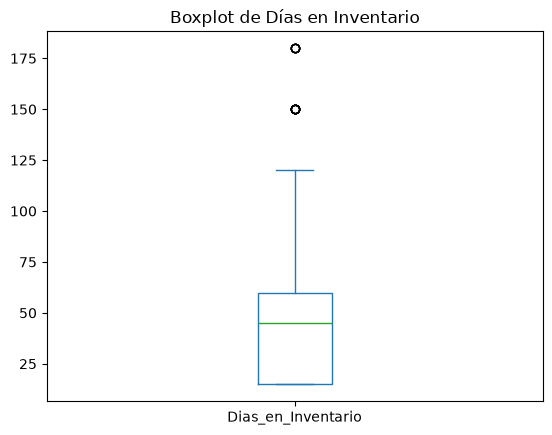

In [ ]:
df['Dias_en_Inventario'].plot(kind='box', title='Boxplot de Días en Inventario')

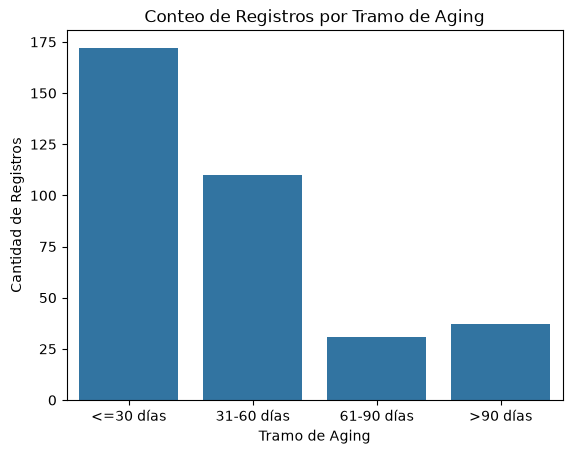

In [25]:
sns.countplot(data=df, x='Tramo_Aging')
plt.title('Conteo de Registros por Tramo de Aging')
plt.xlabel('Tramo de Aging')
plt.ylabel('Cantidad de Registros')
plt.show()

In [28]:
print(df['Tramo_Aging'].value_counts())

Tramo_Aging
<=30 días     172
31-60 días    110
>90 días       37
61-90 días     31
Name: count, dtype: int64


In [29]:
37+31

68

En numeros absolutos, hay 68 vehículos que estuvieron más de 2 meses en el inventario. En particular, 37 vehículos que estuvieron más de 3 meses, estos representan los más críticos y que necesitan/necesitaron de reasignación o liquidación.

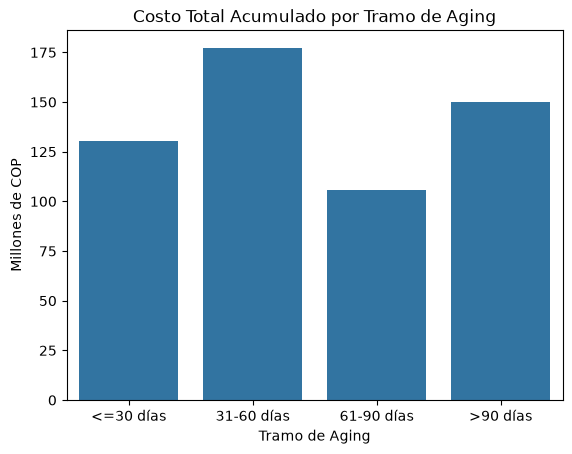

In [36]:
df['Holding_Cost_Millones'] = df['Holding_Cost_COP'] / 1_000_000
sns.barplot(data=df, x='Tramo_Aging', y='Holding_Cost_Millones', estimator='sum', errorbar=None)
plt.title('Costo Total Acumulado por Tramo de Aging')
plt.xlabel('Tramo de Aging')
plt.ylabel('Millones de COP')
plt.show()

Esto se traduce a que el costo del 25% de vehículos que más se tiempo están en el inventario producen el mismo costo que el 75% restante.